# Training Outline
## Zero Shot Training
The purpose of this training is to get the embeddings for use in slider font customization.

# GRID

In [1]:
# Importing
from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

c:\Users\windo\Desktop\TheFontinator\datawork\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 14227.43it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [2]:
import torch
from transformers import AutoModel
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model.to(device)
# Ensure input tensors are also on the 'device'

Using device: cpu


CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [3]:
# Ensure you are running on GPU if possible.
print(model.device)

cpu


In [4]:
from PIL import Image

def embed_image(image_path):
    image = Image.open(image_path)

    inputs = processor(
        images=image,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        image_features = model.get_image_features(**inputs)

    # Extract the tensor if it's a model output object
    if hasattr(image_features, 'pooler_output'):
        image_features = image_features.pooler_output
    elif hasattr(image_features, 'last_hidden_state'):
        image_features = image_features.last_hidden_state[:, 0, :]  # CLS token

    image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    return image_features.cpu().numpy()[0]

In [5]:
embed_image("font-photos/silkscreen.png")

array([ 2.31902990e-02,  3.83126065e-02,  4.23989184e-02, -1.44687761e-02,
        4.65840995e-02, -4.23696376e-02,  2.67917886e-02,  2.27828156e-02,
        6.98908186e-03,  8.05616081e-02,  3.86845623e-03, -3.24037559e-02,
        2.75414698e-02, -1.90484021e-02,  6.15060255e-02, -5.14397584e-03,
        2.67098229e-02, -1.58797372e-02,  5.77327237e-03, -1.42455688e-02,
       -1.43703248e-03, -3.41998711e-02, -1.36837352e-03,  3.99114303e-02,
       -7.07990825e-02,  2.43778955e-02, -3.21350470e-02,  3.73570919e-02,
       -4.47937194e-03, -1.33087356e-02,  4.07748111e-02,  6.31652586e-03,
        2.24192943e-02, -3.50496382e-03,  1.04356315e-02, -4.20066230e-02,
        4.78915647e-02,  1.46345878e-02, -2.91300094e-05, -8.70085061e-02,
       -1.79643538e-02, -2.83717010e-02, -4.31010388e-02, -4.80932742e-02,
        2.47997437e-02,  1.18294740e-02,  4.28591296e-02, -2.55740322e-02,
       -8.71595053e-04,  6.58745393e-02,  2.34802235e-02,  7.71545572e-03,
        1.97214633e-02,  

In [6]:
import os
import numpy as np
from tqdm import tqdm

image_dir = "font-photos"

embeddings = []
font_ids = []

for fname in tqdm(os.listdir(image_dir)):
    if fname.endswith(".png"):
        path = os.path.join(image_dir, fname)
        emb = embed_image(path)

        embeddings.append(emb)
        font_ids.append(fname.replace(".png", ""))

embeddings = np.vstack(embeddings)


100%|██████████| 1190/1190 [03:01<00:00,  6.56it/s]


In [7]:
font_ids

['abeezee',
 'abel',
 'aboreto',
 'abrilfatface',
 'acme',
 'actor',
 'adamina',
 'adventpro',
 'afacad',
 'afacadflux',
 'agbalumo',
 'agdasima',
 'aguafinascript',
 'agudisplay',
 'akronim',
 'aladin',
 'alansans',
 'alata',
 'alatsi',
 'albertsans',
 'aldrich',
 'alegreya',
 'alegreyasans',
 'alegreyasanssc',
 'alegreyasc',
 'aleo',
 'alexbrush',
 'alfaslabone',
 'alice',
 'alike',
 'alikeangular',
 'alkatra',
 'allan',
 'allerta',
 'allertastencil',
 'allison',
 'allura',
 'almendra',
 'almendradisplay',
 'almendrasc',
 'alumnisans',
 'alumnisanscollegiateone',
 'alumnisanscollegiateonesc',
 'alumnisansinlineone',
 'alumnisanspinstripe',
 'alumnisanssc',
 'amarante',
 'amaranth',
 'amarna',
 'amaticsc',
 'amethysta',
 'anaheim',
 'ancizarsans',
 'ancizarserif',
 'andadapro',
 'andika',
 'aneklatin',
 'annieuseyourtelescope',
 'anonymouspro',
 'anta',
 'antic',
 'anticdidone',
 'anticslab',
 'anton',
 'antonio',
 'antonsc',
 'anybody',
 'arapey',
 'arbutus',
 'arbutusslab',
 'archit

In [8]:
embeddings

array([[ 0.01264298,  0.0245486 ,  0.00655077, ...,  0.02151509,
        -0.04468042,  0.00866816],
       [ 0.002914  ,  0.03322282,  0.01043016, ...,  0.01874157,
        -0.04470762,  0.02835444],
       [ 0.00096413,  0.05744144,  0.0187967 , ...,  0.03034932,
        -0.05313124,  0.00453151],
       ...,
       [-0.02809093,  0.02185095, -0.00655766, ...,  0.04655302,
        -0.00412596, -0.01807649],
       [ 0.00868379,  0.03357442,  0.00972469, ...,  0.03105973,
        -0.0435291 ,  0.01613091],
       [ 0.00101636,  0.01061434, -0.03218983, ...,  0.01555501,
        -0.01443931,  0.02380759]], shape=(1190, 512), dtype=float32)

In [9]:
font_ids.index("silkscreen")

1014

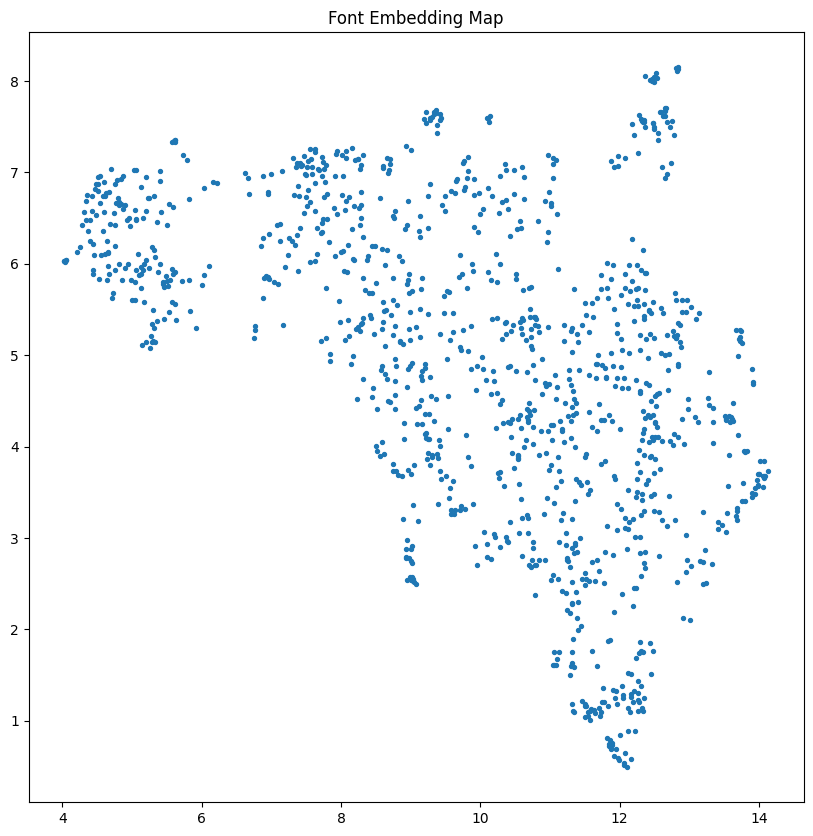

In [10]:
import umap
import matplotlib.pyplot as plt


# Using this to make our 2d embedding map
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine"
)

coords = reducer.fit_transform(embeddings)

plt.figure(figsize=(10, 10))
plt.scatter(coords[:, 0], coords[:, 1], s=8)
plt.title("Font Embedding Map")
plt.show()


In [11]:
import numpy as np
from math import ceil, sqrt

n = coords.shape[0]
grid_size = ceil(sqrt(n))

xs = np.linspace(coords[:,0].min(), coords[:,0].max(), grid_size)
ys = np.linspace(coords[:,1].min(), coords[:,1].max(), grid_size)

grid = np.array([
    (x, y)
    for y in ys
    for x in xs
])[:n]


In [24]:
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

cost = cdist(coords, grid)
row_ind, col_ind = linear_sum_assignment(cost)

grid_coords = grid[col_ind]

# After computing grid_coords = grid[col_ind]

# Compute integer grid positions
grid_size = ceil(sqrt(n))
integer_grid_coords = np.array([[idx // grid_size, idx % grid_size] for idx in col_ind])

# Save the integer Grid Coords instead
proj_dir = os.path.dirname(os.getcwd())  # Goes up one level to TheFontinator/
save_path = os.path.join(proj_dir, 'backend', 'data', 'IntGridCoords.npy')
np.save(save_path, integer_grid_coords)


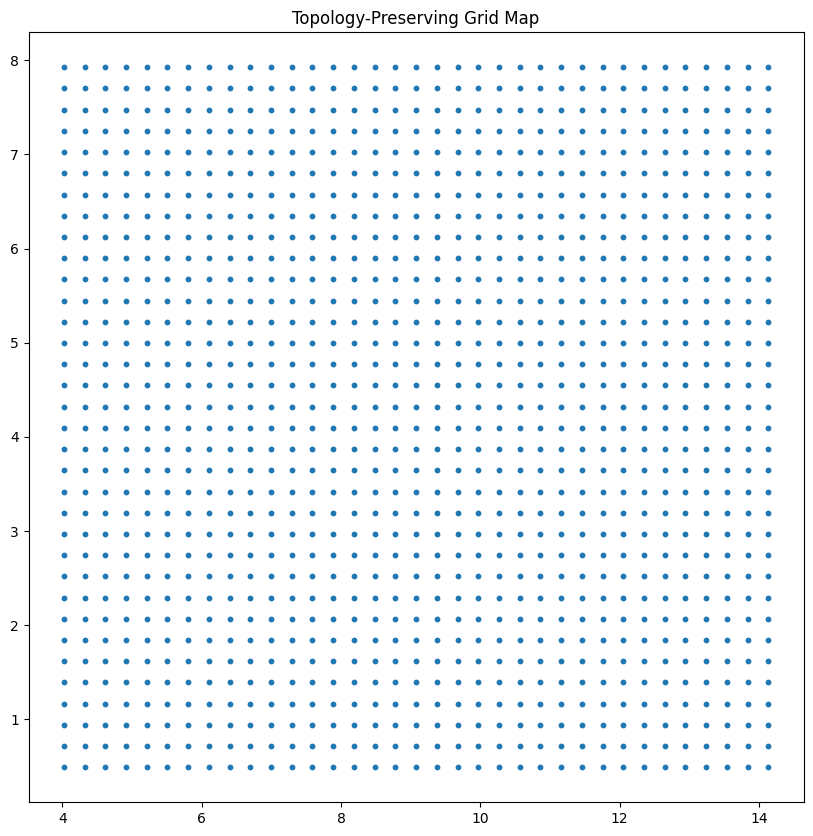

In [25]:
plt.figure(figsize=(10, 10))
plt.scatter(grid_coords[:, 0], grid_coords[:, 1], s=10)
plt.title("Topology-Preserving Grid Map")
plt.show()


In [26]:
# Grid Coords still match up in order of font_ids
grid_coords

array([[11.757143 ,  6.7991643],
       [12.352301 ,  2.7436004],
       [ 9.078934 ,  4.996691 ],
       ...,
       [ 4.9128294,  5.672619 ],
       [ 5.507987 ,  2.9689095],
       [12.054722 ,  6.7991643]], shape=(1190, 2), dtype=float32)

In [27]:
# Named font data because I'll probably expand this table to have metadata
# Converts to numpy for now
font_ids_np = np.array(font_ids)


# Save the Grid Coords and the id's for use in backend
save_path = os.path.join(proj_dir, 'backend', 'data', 'GridCoords.npy')
np.save(save_path, grid_coords)


# Named font data because I'll probably expand this table to have metadata
# Converts to numpy for now
save_path = os.path.join(proj_dir, 'backend', 'data', 'FontData.npy')
np.save(save_path, font_ids_np)

In [28]:
font_ids_np

array(['abeezee', 'abel', 'aboreto', ..., 'zeyada', 'zillaslab',
       'zillaslabhighlight'], shape=(1190,), dtype='<U28')

# Embedding Sliders

buisness, fancy, calm, playfull, cute, artistic, vintage, loud, sophisticated, futuristic, active, stiff, innovative, happy, childlike, rugged, awkward, excited

In [ ]:
sliders = {
    "seriousness": [
        "serious professional corporate font",
        "playful fun cartoon font"
    ],
    "modernness": [
        "modern clean minimalist font",
        "classic traditional old font"
    ],
    "elegance": [
        "elegant luxury fashion font",
        "loud bold display font"
    ],
    "personal": [
        "human handwritten script font",
        "technical computer font"
    ],
    "energy": [
    "energetic dynamic expressive font",
    "calm stable restrained font"
    ],
    "density": [
      "compact dense information-heavy font",
      "open airy spacious font"
    ],
    "readability": [
    "highly readable clear body text font",
    "expressive decorative hard to read font"
    ]
}


: 

: 

In [ ]:
# classes = [] # get all slider values in here

: 

: 

In [ ]:
sliders["seriousness"]

['serious professional corporate font', 'playful fun cartoon font']

: 

: 

In [ ]:
img_emb = embed_image("font-photos/alexbrush.png")

: 

: 

In [ ]:
image_dir = "font-photos"

for slider in sliders:
  img_probs = None
  # embeddings = []

  slider_font_ids = []

  for fname in tqdm(os.listdir(image_dir)):
      if fname.endswith(".png"):
          image_path = os.path.join(image_dir, fname)
          image = Image.open(image_path)
          inputs = processor(text=classes, images=image, return_tensors="pt", padding=True, do_convert_rgb=False)
          outputs = model(**inputs)

          logits_per_image = outputs.logits_per_image  # this is the image-text similarity score
          probs = logits_per_image.softmax(dim=1)  # we can take the softmax to get the label probabilities

          img_probs.append(emb)
          slider_font_ids.append(fname.replace(".png", ""))

probabilities = np.vstack(img_probs)

  0%|          | 0/1180 [00:00<?, ?it/s]


ValueError: Unsupported number of image dimensions: 2

: 

: 

In [ ]:
classes = ['giraffe', 'zebra', 'elephant']

inputs = processor(text=classes, images=images, return_tensors="pt", padding=True, do_convert_rgb=False)

outputs = model(**inputs)
logits_per_image = outputs.logits_per_image  # this is the image-text similarity score
probs = logits_per_image.softmax(dim=1)  # we can take the softmax to get the label probabilities

: 

: 

In [ ]:
image_dir = "font-photos"

embeddings = []
font_ids = []

for fname in tqdm(os.listdir(image_dir)):
    if fname.endswith(".png"):
        path = os.path.join(image_dir, fname)

        emb = embed_image(path)

        embeddings.append(emb)
        font_ids.append(fname.replace(".png", ""))

embeddings = np.vstack(embeddings)


: 

: 

In [ ]:
grid_coords = np.load(proj_dir + '/backend/data/GridCoords.npy')

: 

: 

In [ ]:
grid_coords

array([[ 2.895771 ,  8.435083 ],
       [ 7.9715347,  4.027959 ],
       [ 8.568684 , 10.363201 ],
       ...,
       [ 4.0900683, 11.189537 ],
       [11.554426 ,  5.956076 ],
       [ 2.895771 ,  4.854295 ]], shape=(1180, 2), dtype=float32)

: 

: 

In [ ]:
# Add this code after loading grid_coords to convert the float coordinates to integer grid positions

import numpy as np
from math import ceil, sqrt

# Assuming grid_coords is the loaded 1180x2 array
n = grid_coords.shape[0]
grid_size = ceil(sqrt(n))

# Recreate xs and ys (assuming coords is available from earlier, or load embeddings and recompute)
# If coords is not available, you need to recompute or load it
# For now, assuming coords is available from the UMAP step

# If not, you can approximate min and max from grid_coords itself, but better to use original
# To be precise, let's assume we recompute xs and ys based on the original coords

# But since the notebook has coords from UMAP, in practice, run this after the UMAP cell.

# For this code, assuming coords is defined.

xs = np.linspace(grid_coords[:,0].min(), grid_coords[:,0].max(), grid_size)
ys = np.linspace(grid_coords[:,1].min(), grid_coords[:,1].max(), grid_size)

# Now, for each point in grid_coords, find the closest row and col
integer_grid_coords = []
for x, y in grid_coords:
    col = np.argmin(np.abs(xs - x))
    row = np.argmin(np.abs(ys - y))
    integer_grid_coords.append([row, col])

integer_grid_coords = np.array(integer_grid_coords)

# Now integer_grid_coords is a 1180x2 array of integers representing row, col
print(integer_grid_coords)

# Optionally, save it
proj_dir = os.getcwd().rsplit('/', 1)[0]
np.save(proj_dir + '/backend/data/GridCoords_integers', integer_grid_coords)

[[22  2]
 [ 5 19]
 [29 21]
 ...
 [32  6]
 [12 31]
 [ 8  2]]


: 

: 

: 

: 